# Differential Rotation
Considering the $v_\phi$ component of the velocity field averaged over longitude and time, we also computed the differential rotation state for the different cases. The $(r, \theta)$ differential rotation profiles are represented in Fig. 12. - Breton (2022)

In [133]:
import cj_plotter

In [134]:
from music_scripts.musicdata import MusicData

In [135]:
import numpy as np

In [136]:
# sim = MusicData('z2_data/r_min0.4_r_max0.9_from2d_v0_Om0/params_sample.nml')
# sim = MusicData('z2_data/r_min0.4_r_max0.9_from2d_v0_Om1/params_updated.nml')
sim = MusicData('z2_data/r_min0.4_r_max0.9_from2d_v0_Om5/params_updated.nml')

In [137]:
vel_3 = sim[2000].field['vel_3'].array()

In [138]:
v_phi_mean = np.mean(vel_3, axis = 2)

In [139]:
r_tot = 70774597466.3827

In [140]:
r = sim[2000].grid.r_grid.cell_points()
t = sim[2000].grid.theta_grid.cell_points()
p = sim[2000].grid.phi_grid.cell_points()

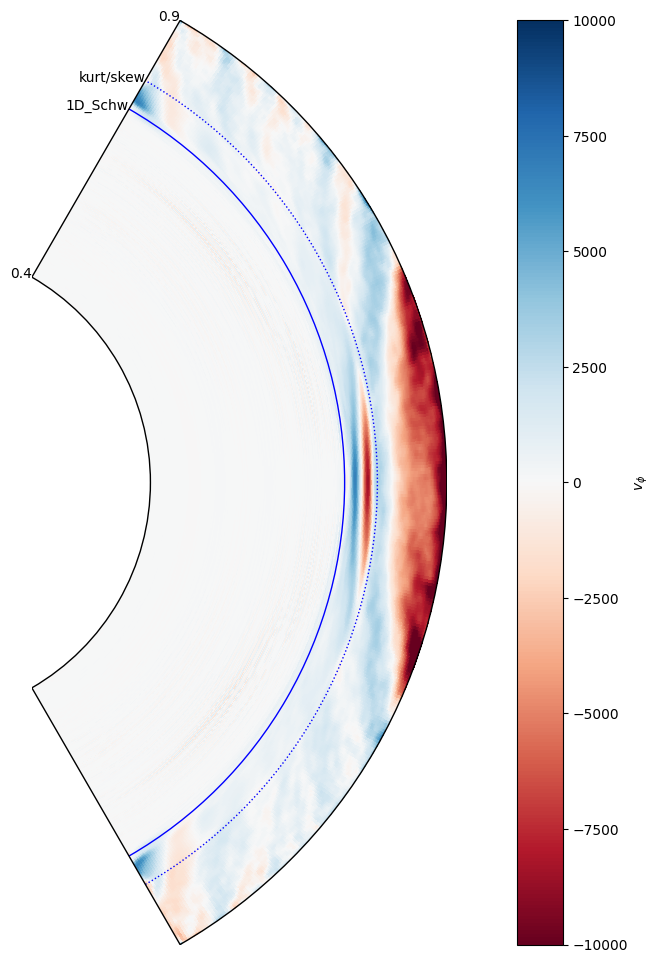

In [141]:
example_plot = cj_plotter.plot2D(t, r/r_tot, v_phi_mean, -1e4, 1e4, cmap='RdBu')

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')

example_plot.colorbar(label=r'$v_\phi$')

In [142]:
end = 2050

In [143]:
# vel_3 = sim[2000].field['vel_3'].array()
# v_phi_mean = np.mean(vel_3, axis = 2)
# running_mean = v_phi_mean.copy()
# count = 1
# for i in range(2000 + 1,end + 1):
#     count += 1
#     vel_3 = sim[i].field['vel_3'].array()
#     v_phi_mean = np.mean(vel_3, axis = 2)
#     running_mean = running_mean + (v_phi_mean - running_mean) / count
#     print(i)


In [144]:
v_phi_mean = running_mean.copy()

NameError: name 'running_mean' is not defined

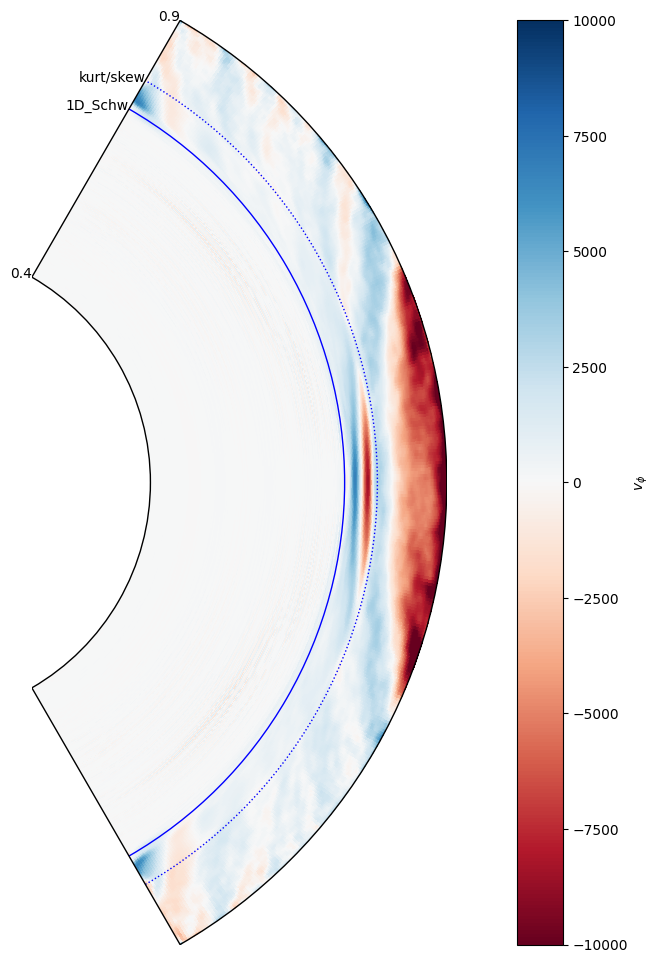

In [145]:
example_plot = cj_plotter.plot2D(t, r/r_tot, v_phi_mean, -1e4, 1e4, cmap='RdBu')

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')

example_plot.colorbar(label=r'$v_\phi$')

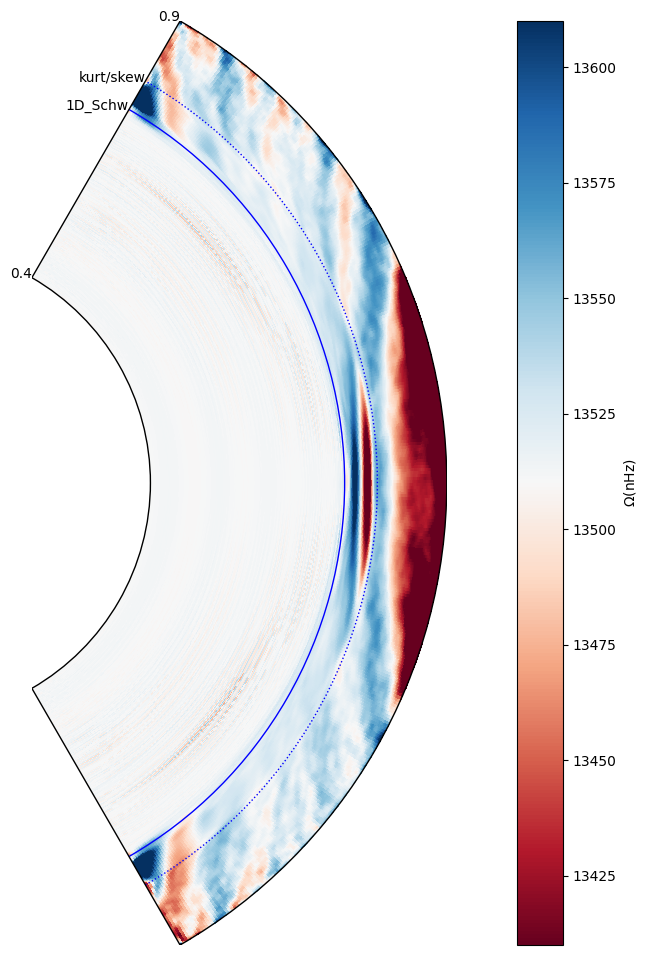

In [146]:
R, T = np.meshgrid(r,t, indexing='ij')
denom = R * np.sin(T)

example_plot = cj_plotter.plot2D(t, r/r_tot, 13.51e-6 * 1e9 + (v_phi_mean / denom) * 1e9, 13.51e-6 * 1e9 - 100, 13.51e-6 * 1e9 + 100, cmap='RdBu')

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')

example_plot.colorbar(label=r'$\Omega$(nHz)')

### Vorticity formula
$$\omega_r = \frac{1}{r \sin \theta}\left( \frac{\partial(v_{\phi} \sin \theta)}{\partial\theta} - \frac{\partial v_{\theta}}{\partial \phi} \right)$$
$$\omega_\theta = \frac{1}{r}\left(\frac{1}{\sin \theta} \frac{\partial v_r}{\partial \phi}-\frac{\partial}{\partial r}\left(r v_{\phi}\right)\right)$$
$$\omega_\phi = \frac{1}{r}\left(\frac{\partial}{\partial r}\left(r v_\theta\right)-\frac{\partial v_r}{\partial \theta}\right)$$

In [147]:
def vorticity(vel_1, vel_2, vel_3, r, t, p):
    sin_theta = np.sin(t)[np.newaxis, :, np.newaxis]
    r_3D = r[:, np.newaxis, np.newaxis]

    v_3_sin_theta = vel_3 * sin_theta

    dv_3_sin_theta_dtheta = np.gradient(v_3_sin_theta, t, axis = 1)

    dv_2_dphi = np.gradient(vel_2, p, axis = 2)

    vorticity_1 = (dv_3_sin_theta_dtheta - dv_2_dphi) / (r_3D * sin_theta)

    dv_1_dphi = np.gradient(vel_1, p, axis = 2)

    rv_3 = r_3D * vel_3

    drv_3_dr = np.gradient(rv_3, r, axis = 0)

    vorticity_2 = (dv_1_dphi / sin_theta - drv_3_dr) / r_3D

    rv_2 = r_3D * vel_2

    drv_2_dr = np.gradient(rv_2, r, axis = 0)

    dv_1_dtheta = np.gradient(vel_1, t, axis = 1)

    vorticity_3 = (drv_2_dr - dv_1_dtheta) / r_3D

    return vorticity_1, vorticity_2, vorticity_3

In [148]:
vel_1 = sim[2000].field['vel_1'].array()
vel_2 = sim[2000].field['vel_2'].array()
vel_3 = sim[2000].field['vel_3'].array()

In [149]:
vel_3_prime = vel_3 - v_phi_mean[:,:,np.newaxis]

In [150]:
vorticity_1, vorticity_2, vorticity_3 = vorticity(vel_1, vel_2, vel_3_prime, r, t, p)

In [151]:
vorticity_abs = np.sqrt(vorticity_1**2 + vorticity_2**2 + vorticity_3**2)

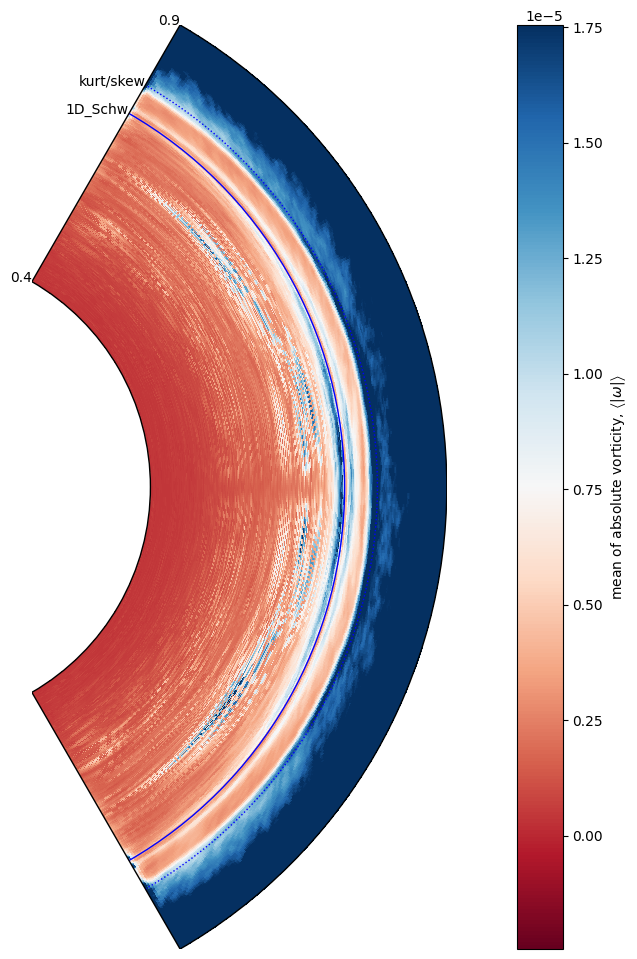

In [152]:
example_plot = cj_plotter.plot2D(t, r/r_tot, np.mean(vorticity_abs, axis = 2), vorticity_abs.mean() - 1e-5, vorticity_abs.mean() + 1e-5, cmap='RdBu')

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')

example_plot.colorbar(label=r'mean of absolute vorticity, $\left<|\omega|\right>$')

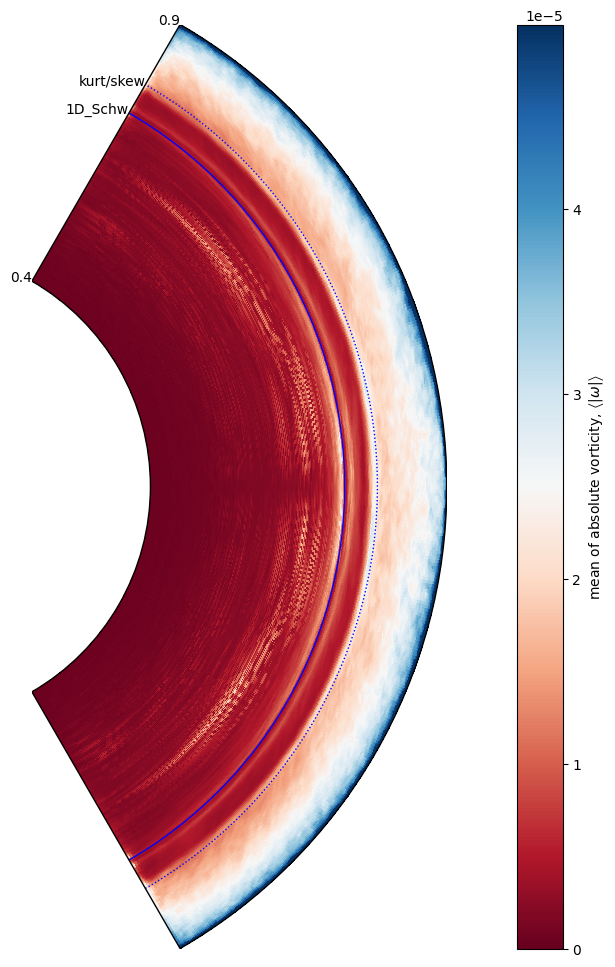

In [166]:
example_plot = cj_plotter.plot2D(t, r/r_tot, np.sqrt(np.mean(vorticity_abs ** 2, axis = 2)), 0, vorticity_1.mean() + 5e-5, cmap='RdBu')

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')

example_plot.colorbar(label=r'mean of absolute vorticity, $\left<|\omega|\right>$')

### Fluid Rossby
$$\text{Ro}_f = \frac{|\nabla \times v|}{2\Omega_0}$$

In [154]:
# Omega = 0
# Omega = 2.702e-6
Omega = 13.51e-6

In [155]:
import matplotlib.pyplot as plt

In [167]:
Ro_f = np.sqrt(np.mean(np.mean(vorticity_abs ** 2, axis = 2), axis = 1)) / (2 * Omega)

In [168]:
Ro_f.shape

(504,)

In [203]:
Ro_f = np.sqrt(area_average(vorticity_abs ** 2, t)) / (2 * Omega)

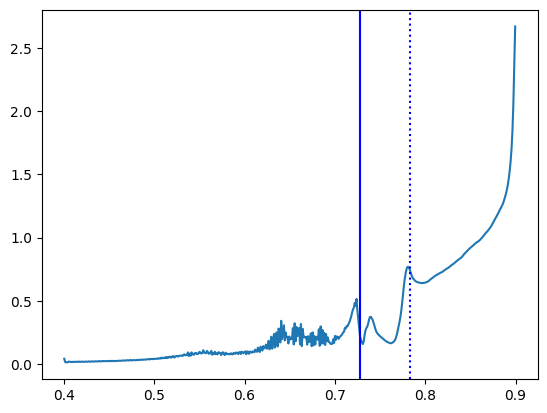

In [204]:
fig, ax = plt.subplots()
ax.plot(r/r_tot, Ro_f)
ax.axvline(5.149819426617924E+10/r_tot, c='blue', label='1D_Schw')
ax.axvline(55412016190.5/r_tot, c='blue', linestyle=':', label='kurt/skew')

### Local Rossby
$$\Omega = \Omega_0 + \frac{\left<v_\phi\right>_\phi}{r\sin\theta}$$
$$\text{Ro} = \frac{\omega}{f}$$
$$\text{Ro} = \frac{\omega}{|2\Omega\cos\theta|}$$
$$\text{Ro} = \frac{\left|\zeta\right|}{\left|2\left(\Omega_0 + \frac{\left<v_\phi\right>_\phi}{r\sin\theta}\right)\cos\theta\right|}$$

In [171]:
Omega_true = Omega + v_phi_mean / (r[:, np.newaxis] * np.sin(t))
Denom = abs(2 * Omega_true * np.cos(t))
Rossby = vorticity_1 / Denom[:,:,np.newaxis]

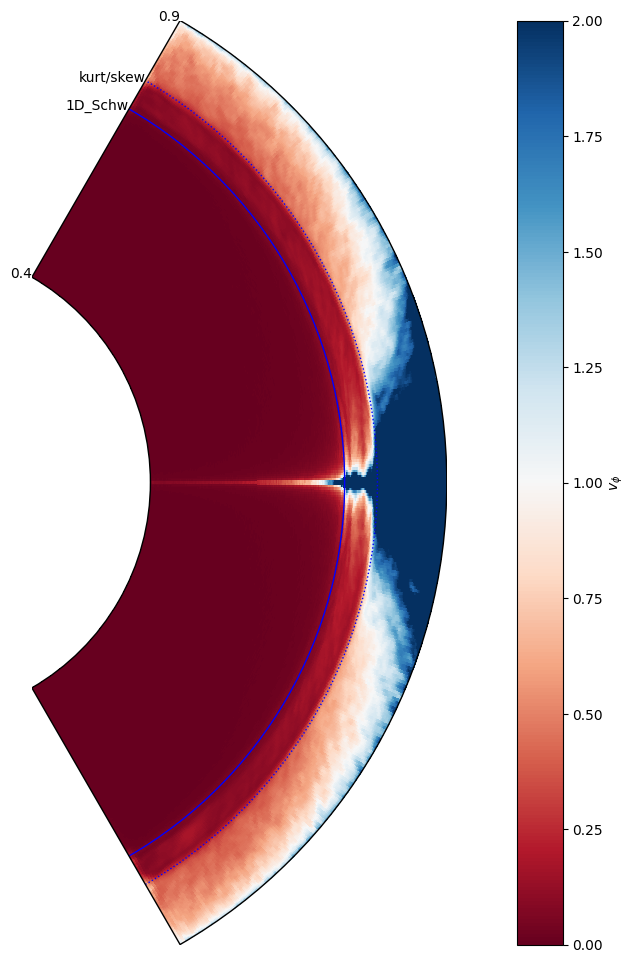

In [173]:
example_plot = cj_plotter.plot2D(t, r/r_tot, np.sqrt(np.mean(Rossby ** 2, axis=2)), 0, 2, cmap='RdBu')

example_plot.add_arc(5.149819426617924E+10/r_tot, edgecolor='blue', label='1D_Schw')
example_plot.add_arc(55412016190.5/r_tot, edgecolor='blue', linestyle=':', label='kurt/skew')

example_plot.colorbar(label=r'$v_\phi$')

Im really not liking the look of this so far

In [194]:
def area_average(arr_3D, theta):
    """
    arr_3D : (Nr, Ntheta, Nphi)
    theta  : 1D array (Ntheta,) in radians
    returns: (Nr,) area‑weighted average over theta & phi
    """
    Nphi = arr_3D.shape[2]
    # 1. Sum over phi (simple arithmetic mean first)
    sum_phi = np.sum(arr_3D, axis=2)                 # (Nr, Ntheta)
    # 2. Weighted sum over theta using sin(theta)
    weighted_sum = np.sum(sum_phi * np.sin(theta), axis=1)   # (Nr,)
    # 3. Normalise by total weight (sum(sinθ) * Nphi)
    total_weight = np.sum(np.sin(theta)) * Nphi
    return weighted_sum / total_weight

### Global Rossby

In [205]:
v_rms = np.sqrt(area_average((vel_1 ** 2 + vel_2 ** 2 + vel_3 ** 2), t))


In [214]:
np.argmin(abs(r - 5.149819426617924E+10))

np.int64(330)

In [228]:
t_conv_vel_rms = np.diff(r).mean() * np.sum((1 / v_rms)[330:-1])

In [230]:
Ro = 2 * np.pi / (t_conv_vel_rms * Omega)

In [231]:
Ro

np.float64(0.20319310086331685)

In [232]:
vel_1_rms = np.sqrt(area_average(vel_1 ** 2, t))
t_conv_vel_1_rms = np.diff(r).mean() * np.sum((1 / vel_1_rms)[330:-1])
Ro = 2 * np.pi / (t_conv_vel_1_rms * Omega)
Ro

np.float64(0.0392067193829448)

In [247]:
t_conv_breton = (r[-1] - r[330]) / np.mean(vel_1_rms[330:])
Ro = 2 * np.pi / (t_conv_breton * Omega)
Ro

np.float64(0.15326401840883716)

In [257]:
sim = MusicData('z2_data/r_min0.4_r_max0.9_from2d_v0_Om1/params_updated.nml')

In [258]:
vel_1 = sim[2000].field['vel_1'].array()
vel_2 = sim[2000].field['vel_2'].array()
vel_3 = sim[2000].field['vel_3'].array()

In [259]:
v_rms = np.sqrt(area_average((vel_1 ** 2 + vel_2 ** 2 + vel_3 ** 2), t))


In [260]:
t_conv_vel_rms = np.diff(r).mean() * np.sum((1 / v_rms)[330:-1])

In [261]:
Omega = 2.702e-6
Ro = 2 * np.pi / (t_conv_vel_rms * Omega)

In [262]:
Ro

np.float64(1.0051598764206229)